In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import pickle

print("All libraries imported successfully!")

All libraries imported successfully!


In [12]:
Development = pd.read_csv("../Dataset/HDI.csv", encoding="latin1")

Development.head()

,Unnamed: 0,iso3,country,hdicode,hdi_rank_2022,gii_rank_2022,year,hdi,life_expectancy,pop_millions,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,1,AFG,Afghanistan,Low,182.0,162.0,1990,0.284,45.967,10.694796,...,NaN,NaN,1.107733,7.899011,NaN,NaN,NaN,NaN,0.189279,2.1809
1,2,AFG,Afghanistan,Low,182.0,162.0,1991,0.292,46.663,10.745167,...,NaN,NaN,1.221396,8.137953,NaN,NaN,NaN,NaN,0.178155,2.5264
2,3,AFG,Afghanistan,Low,182.0,162.0,1992,0.299,47.596,12.057433,...,NaN,NaN,1.335059,8.376896,NaN,NaN,NaN,NaN,0.122920,2.6421
3,4,AFG,Afghanistan,Low,182.0,162.0,1993,0.307,51.466,14.003760,...,NaN,NaN,1.448722,8.615838,NaN,NaN,NaN,NaN,0.106179,2.3022
4,5,AFG,Afghanistan,Low,182.0,162.0,1994,0.300,51.495,15.455554,...,NaN,NaN,1.562385,8.854780,NaN,NaN,NaN,NaN,0.094063,1.8948


In [13]:
Development.shape

(6798, 33)

In [14]:
Development.info()

<class 'pandas.DataFrame'>
RangeIndex: 6798 entries, 0 to 6797
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 6798 non-null   int64  
 1   iso3                       6798 non-null   str    
 2   country                    6798 non-null   str    
 3   hdicode                    6369 non-null   str    
 4   hdi_rank_2022              6369 non-null   float64
 5   gii_rank_2022              5478 non-null   float64
 6   year                       6798 non-null   int64  
 7   hdi                        6171 non-null   float64
 8   life_expectancy            6798 non-null   float64
 9   pop_millions               6798 non-null   float64
 10  hdi_f                      5014 non-null   float64
 11  hdi_m                      5014 non-null   float64
 12  life_expec_f               6798 non-null   float64
 13  life_expec_m               6798 non-null   float64
 14  exp

In [15]:
Development.describe()

,Unnamed: 0,hdi_rank_2022,gii_rank_2022,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
count,6798.000000,6369.000000,5478.000000,6798.000000,6171.000000,6798.000000,6798.000000,5014.000000,5014.000000,6798.000000,...,5014.000000,4711.000000,5817.000000,5817.000000,6269.000000,6269.000000,5310.000000,5310.000000,6713.000000,5344.000000
mean,3399.500000,96.854922,83.500000,2006.000000,0.670293,68.544884,122.703025,0.671530,0.713682,71.189861,...,0.931731,0.390031,49.855594,56.345271,16.507989,83.492011,49.318145,72.360992,4.520991,12.769886
std,1962.557897,55.771006,47.923577,9.522605,0.164414,9.501335,561.825531,0.166486,0.143888,9.911176,...,0.075246,0.192830,29.853427,27.272712,10.928861,10.928861,15.797188,9.196551,6.241956,12.359313
min,1.000000,1.000000,1.000000,1990.000000,0.212000,14.098000,0.009182,0.191917,0.274102,15.663000,...,0.383000,0.009000,0.420000,2.050000,0.010000,42.452830,5.610000,29.630000,0.019352,0.000100
25%,1700.250000,49.000000,42.000000,1998.000000,0.546500,62.687250,1.989805,0.552527,0.611195,65.038500,...,0.898000,0.224000,23.369720,33.802000,8.333333,77.272727,40.552500,66.720000,0.624496,4.137650
50%,3399.500000,97.000000,83.500000,2006.000000,0.692000,70.491500,7.914909,0.694996,0.728110,73.684000,...,0.954000,0.404000,49.100111,54.533215,14.545455,85.454545,50.780000,73.020000,2.340953,8.523550
75%,5098.750000,145.000000,125.000000,2014.000000,0.797000,75.419894,28.194687,0.804586,0.817185,78.549500,...,0.982000,0.547500,76.408417,81.527327,22.727273,91.666667,58.235000,78.600000,6.221754,17.442200
max,6798.000000,193.000000,166.000000,2022.000000,0.967000,86.895000,7940.608797,0.957148,0.977383,88.881000,...,1.072000,0.838000,100.000000,100.000000,57.547170,99.990000,94.400000,100.000000,76.612949,140.815700


In [16]:
Development.isnull().sum()

Unnamed: 0                      0
iso3                            0
country                         0
hdicode                       429
hdi_rank_2022                 429
gii_rank_2022                1320
year                            0
hdi                           627
life_expectancy                 0
pop_millions                    0
hdi_f                        1784
hdi_m                        1784
life_expec_f                    0
life_expec_m                    0
expec_yr_school               248
expec_yr_school_f             528
expec_yr_school_m             528
mean_yr_school                544
mean_yr_school_f              634
mean_yr_school_m              634
gross_inc_percap              139
gross_inc_percap_f           1506
gross_inc_percap_m           1506
gender_development           1784
gender_inequality            2087
secondary_education_f_%       981
secondary_education_m_%       981
seats_in_parliament_f_%       529
seats_in_parliament_m_%       529
labour_partici

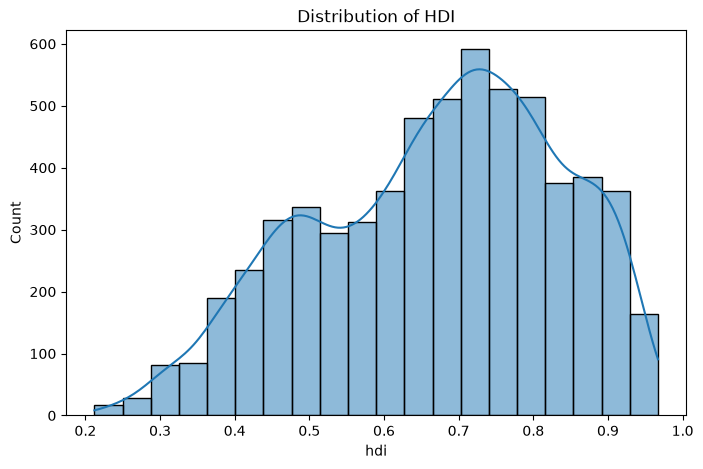

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(Development["hdi"], bins=20, kde=True)
plt.title("Distribution of HDI")
plt.show()

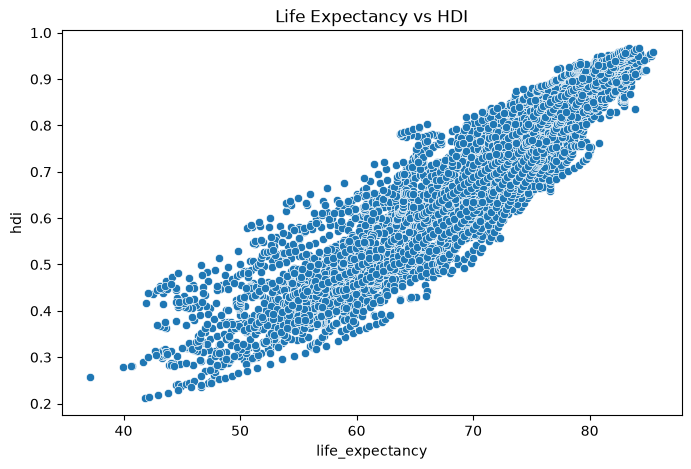

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="life_expectancy", y="hdi", data=Development)
plt.title("Life Expectancy vs HDI")
plt.show()

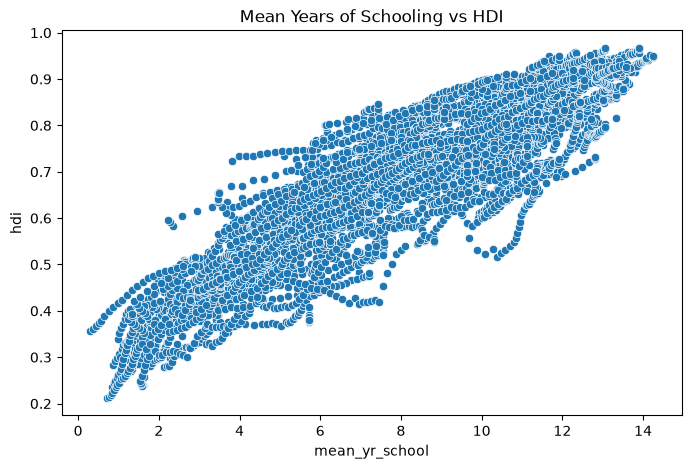

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="mean_yr_school", y="hdi", data=Development)
plt.title("Mean Years of Schooling vs HDI")
plt.show()

In [20]:
Development.columns

Index(['Unnamed: 0', 'iso3', 'country', 'hdicode', 'hdi_rank_2022',
       'gii_rank_2022', 'year', 'hdi', 'life_expectancy', 'pop_millions',
       'hdi_f', 'hdi_m', 'life_expec_f', 'life_expec_m', 'expec_yr_school',
       'expec_yr_school_f', 'expec_yr_school_m', 'mean_yr_school',
       'mean_yr_school_f', 'mean_yr_school_m', 'gross_inc_percap',
       'gross_inc_percap_f', 'gross_inc_percap_m', 'gender_development',
       'gender_inequality', 'secondary_education_f_%',
       'secondary_education_m_%', 'seats_in_parliament_f_%',
       'seats_in_parliament_m_%', 'labour_participation_f_%',
       'labour_participation_m_%', 'co2_emission_tons',
       'mat_footprint_percap_tons'],
      dtype='str')

In [21]:
# Independent Variables (Features)
X = Development[[
    "life_expectancy",
    "mean_yr_school",
    "expec_yr_school",
    "gross_inc_percap"
]]

# Dependent Variable (Target)
Y = Development["hdi"]

print("Features (X):")
print(X.head())

print("\nTarget (Y):")
print(Y.head())

Features (X):
   life_expectancy  mean_yr_school  expec_yr_school  gross_inc_percap
0           45.967        0.871962         2.936460       3115.670448
1           46.663        0.915267         3.228456       2817.304736
2           47.596        0.958573         3.520452       2474.681985
3           51.466        1.001878         3.812448       1723.019763
4           51.495        1.045184         4.104445       1202.010488

Target (Y):
0    0.284
1    0.292
2    0.299
3    0.307
4    0.300
Name: hdi, dtype: float64


In [22]:
X.isnull().sum()

life_expectancy       0
mean_yr_school      544
expec_yr_school     248
gross_inc_percap    139
dtype: int64

In [23]:
X = X.fillna(X.mean())

X.isnull().sum()

life_expectancy     0
mean_yr_school      0
expec_yr_school     0
gross_inc_percap    0
dtype: int64

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape :", Y_test.shape)

X_train shape: (5438, 4)
X_test shape : (1360, 4)
Y_train shape: (5438,)
Y_test shape : (1360,)


In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, Y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [26]:
Y.isnull().sum()

np.int64(627)

In [27]:
# Select required columns
data = Development[[
    "life_expectancy",
    "mean_yr_school",
    "expec_yr_school",
    "gross_inc_percap",
    "hdi"
]]

# Remove rows where hdi is missing
data = data.dropna(subset=["hdi"])

# Fill missing values in the input features
data = data.fillna(data.mean(numeric_only=True))

# Create X and Y
X = data[[
    "life_expectancy",
    "mean_yr_school",
    "expec_yr_school",
    "gross_inc_percap"
]]

Y = data["hdi"]

print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in Y:")
print(Y.isnull().sum())

Missing values in X:
life_expectancy     0
mean_yr_school      0
expec_yr_school     0
gross_inc_percap    0
dtype: int64

Missing values in Y:
0


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

print("Model trained successfully!")

Model trained successfully!


In [30]:
Y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(Y_pred[:10])

First 10 Predictions:
[0.83503667 0.54860157 0.39073952 0.78053742 0.41203682 0.60371844
 0.4393497  0.71572247 0.6542642  0.75665132]


In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 0.01691853141120295
Mean Squared Error  : 0.0004958789411069906
Root Mean Squared Error : 0.022268339433082804
R2 Score : 0.9819628342469924


In [32]:
import pickle

with open("../Flask/HDI.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
